In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/05 11:38:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

all_evidence = session.spark.read.parquet(path_to_release_folder + "output/evidence")


efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


g_p_s = session.spark.read.parquet(path_to_intermediate_data_folder + "genes_therapeutic_areas")
g_p_s.count()


26/02/05 11:38:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

# Pharmackoproject data from Minikel et al.


In [9]:
phrm_df = session.spark.read.parquet(path_to_intermediate_data_folder + "minikel_etal_data_processed.parquet")


In [10]:
phrm_df.count()


29481

In [11]:
phrm_df.show(1)


+----------+--------------+----------------+----------+-----------------+
|    meshId|approvedSymbol|maxClinicalPhase|diseaseIds|        targetIds|
+----------+--------------+----------------+----------+-----------------+
|C000656924|         DHODH|               3|        []|[ENSG00000102967]|
+----------+--------------+----------------+----------+-----------------+
only showing top 1 row



In [ ]:
phrm_df_expl = (
    phrm_df.withColumn("targetId", f.explode(f.col("targetIds")))
    .withColumn("diseaseId", f.explode(f.col("diseaseIds")))
    .select("diseaseId", "maxClinicalPhase", "targetId")
    .withColumnRenamed("maxClinicalPhase", "ClinicalPhase")
    .withColumnRenamed("targetId", "geneId")
    .filter(f.col("geneId").isNotNull())
    .filter(f.col("diseaseId").isNotNull())
    .distinct()
)
phrm_df_expl.count()


29222

In [14]:
phrm_df_expl_2 = phrm_df_expl.groupBy("diseaseId", "geneId").agg(
    # 1. Get the highest clinical phase
    f.max("ClinicalPhase").alias("maxClinicalPhase")
)
phrm_df_expl_2.count()


29181

In [15]:
phrm_df_expl_2.count()


29181

In [16]:
phrm_df_expl_2 = phrm_df_expl_2.join(
    g_p_s.select("geneId", "uniqueDiseases", "uniqueTherapeuticAreas"), "geneId", "left"
).fillna({"uniqueDiseases": 0, "uniqueTherapeuticAreas": "0"})

phrm_df_expl_2.count()


29181

In [54]:
phrm_df_expl_2.show(1)


+---------------+-------------+----------------+--------------+----------------------+
|         geneId|    diseaseId|maxClinicalPhase|uniqueDiseases|uniqueTherapeuticAreas|
+---------------+-------------+----------------+--------------+----------------------+
|ENSG00000178562|MONDO_0100096|               2|            15|                     8|
+---------------+-------------+----------------+--------------+----------------------+
only showing top 1 row



In [ ]:
full_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
full_l2g_evidnce.count()


77071

In [ ]:
evid_indirect = chemblDrugEnrichment.evidence_to_indirect_assosiations(
    full_l2g_evidnce,
    disease_index_orig,
    use_max=True,
    efo_to_remove=efo_to_remove,
).cache()
evid_indirect.count()


151704

In [ ]:
evid_indirect = (
    evid_indirect.select("targetId", "diseaseId")
    .withColumnRenamed("targetId", "geneId")
    .withColumn("geneticSupport", f.lit(1))
)


In [ ]:
evid_indirect.show(1)


+---------------+-----------+--------------+
|         geneId|  diseaseId|geneticSupport|
+---------------+-----------+--------------+
|ENSG00000108557|EFO_0001073|             1|
+---------------+-----------+--------------+
only showing top 1 row



In [ ]:
phrm_df_expl_2.count()


16746

In [ ]:
phrm_df_expl_2 = (
    phrm_df_expl_2.join(evid_indirect, ["geneId", "diseaseId"], "left").fillna({"geneticSupport": 0}).cache()
)
phrm_df_expl_2.count()


16746

In [ ]:
phrm_df_expl_2.show(2)


+---------------+-------------+----------------+--------------+----------------------+--------------+
|         geneId|    diseaseId|maxClinicalPhase|uniqueDiseases|uniqueTherapeuticAreas|geneticSupport|
+---------------+-------------+----------------+--------------+----------------------+--------------+
|ENSG00000178562|MONDO_0100096|               2|            15|                     8|             0|
|ENSG00000213809|  EFO_0004192|               2|             2|                     2|             0|
+---------------+-------------+----------------+--------------+----------------------+--------------+
only showing top 2 rows



In [63]:
phrm_df_expl_2 = phrm_df_expl_2.filter(~f.col("diseaseId").isin(efo_to_remove))
phrm_df_expl_2.count()


16746

In [64]:
df = phrm_df_expl_2.toPandas()

df["high_gPS"] = df["uniqueDiseases"].apply(lambda x: int(x) >= 10).astype(int)
df["outcome"] = df["maxClinicalPhase"].apply(lambda x: int(x) == 4).astype(int)
df_support = df[df["uniqueDiseases"] > 0]


In [65]:
df


,geneId,diseaseId,maxClinicalPhase,uniqueDiseases,uniqueTherapeuticAreas,geneticSupport,high_gPS,outcome
0,ENSG00000178562,MONDO_0100096,2,15,8,0,1,0
1,ENSG00000213809,EFO_0004192,2,2,2,0,0,0
2,ENSG00000125538,MONDO_0004975,4,3,2,0,0,1
3,ENSG00000135519,MONDO_0004975,1,1,1,0,0,0
4,ENSG00000198049,EFO_0006788,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...
16741,ENSG00000010671,EFO_0008520,3,0,0,0,0,0
16742,ENSG00000121853,MONDO_0011565,0,1,1,0,0,0
16743,ENSG00000169252,EFO_0000341,4,0,0,0,0,1
16744,ENSG00000162434,EFO_0004610,2,6,5,0,0,0


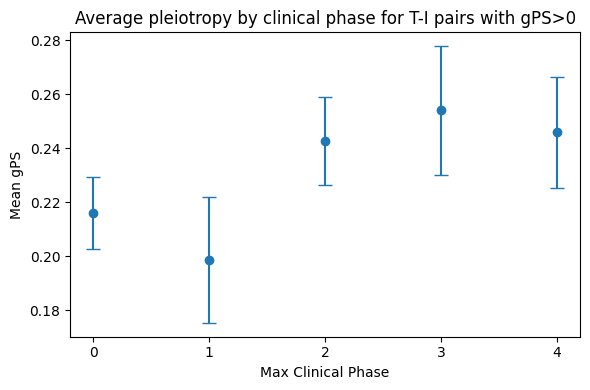

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

summary = df_support.groupby("maxClinicalPhase")["high_gPS"].agg(["mean", "std", "count"])

# Standard error
summary["se"] = summary["std"] / np.sqrt(summary["count"])

# 95% CI (normal approximation)
summary["ci_low"] = summary["mean"] - 1.96 * summary["se"]
summary["ci_high"] = summary["mean"] + 1.96 * summary["se"]

# Ensure all phases present and ordered
summary = summary.reindex([0, 1, 2, 3, 4])

plt.figure(figsize=(6, 4))

plt.errorbar(
    x=summary.index,
    y=summary["mean"],
    yerr=[summary["mean"] - summary["ci_low"], summary["ci_high"] - summary["mean"]],
    fmt="o",
    capsize=5,
)

plt.xticks([0, 1, 2, 3, 4])
plt.xlabel("Max Clinical Phase")
plt.ylabel("Mean gPS")
plt.title("Average pleiotropy by clinical phase for T-I pairs with gPS>0")

plt.tight_layout()
plt.show()


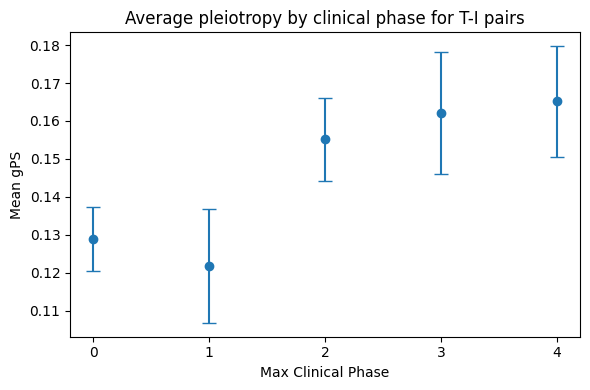

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

summary = df.groupby("maxClinicalPhase")["high_gPS"].agg(["mean", "std", "count"])

# Standard error
summary["se"] = summary["std"] / np.sqrt(summary["count"])

# 95% CI (normal approximation)
summary["ci_low"] = summary["mean"] - 1.96 * summary["se"]
summary["ci_high"] = summary["mean"] + 1.96 * summary["se"]

# Ensure all phases present and ordered
summary = summary.reindex([0, 1, 2, 3, 4])

plt.figure(figsize=(6, 4))

plt.errorbar(
    x=summary.index,
    y=summary["mean"],
    yerr=[summary["mean"] - summary["ci_low"], summary["ci_high"] - summary["mean"]],
    fmt="o",
    capsize=5,
)

plt.xticks([0, 1, 2, 3, 4])
plt.xlabel("Max Clinical Phase")
plt.ylabel("Mean gPS")
plt.title("Average pleiotropy by clinical phase for T-I pairs")

plt.tight_layout()
plt.show()


In [68]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


In [75]:
df_for_regression = df[df["maxClinicalPhase"] >= 0]


In [76]:
model2 = smf.logit("outcome ~ geneticSupport+uniqueDiseases+I(uniqueDiseases ** 2)", data=df_for_regression).fit(
    disp=False
)
model1 = smf.logit("outcome ~ geneticSupport+uniqueDiseases", data=df_for_regression).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df_for_regression).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=41.613, df=2, p=9.2e-10
model1 vs model0: LR=5.920, df=1, p=0.015
model2 vs model1: LR=35.693, df=1, p=2.31e-09


In [79]:
model = smf.logit("outcome ~ geneticSupport", data=df_for_regression).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                16746
Model:                          Logit   Df Residuals:                    16744
Method:                           MLE   Df Model:                            1
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:               0.0001336
Time:                        13:30:36   Log-Likelihood:                -7048.4
converged:                       True   LL-Null:                       -7049.3
Covariance Type:            nonrobust   LLR p-value:                    0.1699
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.7503      0.022    -77.917      0.000      -1.794      -1.706
geneticSupport     0.1209      0.087      1.389      0.165      -0.050       0.292


In [80]:
np.exp(0.2505)


np.float64(1.2846675899260163)

In [81]:
df_for_regression


,geneId,diseaseId,maxClinicalPhase,uniqueDiseases,uniqueTherapeuticAreas,geneticSupport,high_gPS,outcome
0,ENSG00000178562,MONDO_0100096,2,15,8,0,1,0
1,ENSG00000213809,EFO_0004192,2,2,2,0,0,0
2,ENSG00000125538,MONDO_0004975,4,3,2,0,0,1
3,ENSG00000135519,MONDO_0004975,1,1,1,0,0,0
4,ENSG00000198049,EFO_0006788,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...
16741,ENSG00000010671,EFO_0008520,3,0,0,0,0,0
16742,ENSG00000121853,MONDO_0011565,0,1,1,0,0,0
16743,ENSG00000169252,EFO_0000341,4,0,0,0,0,1
16744,ENSG00000162434,EFO_0004610,2,6,5,0,0,0


In [ ]:
model2 = smf.logit(
    "outcome ~ geneticSupport+uniqueTherapeuticAreas+I(uniqueTherapeuticAreas ** 2)", data=df_for_regression
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas", data=df_for_regression).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df_for_regression).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=17.752, df=2, p=0.00014
model1 vs model0: LR=12.686, df=1, p=0.000368
model2 vs model1: LR=5.066, df=1, p=0.0244


26/02/05 18:24:59 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1075312 ms exceeds timeout 120000 ms
26/02/05 18:24:59 WARN SparkContext: Killing executors is not supported by current scheduler.
26/02/05 18:25:06 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$